In [1]:
import pandas as pd
import matplotlib.pyplot as plt 

## 1 red

In [2]:
#2670 originalmente cop / kwh como 1kwh es 1000 mwh entonces es 2670 *1000 cop /mwh, entonces es 2.670.000 que es 2.67 millones 

In [3]:
panel_uniforme1 = pd.read_csv('1red/panel_uniform1R.csv')
panel_uniforme1.head()
#bid en millones

,id_planta,t,h,bid,cantidades_despachadas,precio24,phi
0,1,0,0,2.676840,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.8268800727022, 0.8268800727022, 0.826880072..."
1,2,0,0,3.564928,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.7148847113195, 1.7148847113195, 1.714884711..."
2,3,0,0,3.467680,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.6176457155191, 1.6176457155191, 1.617645715..."
3,4,0,0,2.041678,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1917712637032, 0.1917712637032, 0.191771263..."
4,5,0,0,2.037606,"[164.0, 113.63, 0.0, 0.0, 17.920000000000016, ...","[2.073489846421242, 2.037606479359627, 0.0, 0....","[0.18770034673480002, 0.18770034673480002, 0.1..."


In [4]:
panel_pay_as_bid1 = pd.read_csv('1red/panel_pay_as_bid1R.csv')
panel_pay_as_bid1.head()

,id_planta,t,h,bid,cantidades_despachadas,precio24,phi
0,1,0,0,3.127851,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.8268800727022, 0.8268800727022, 0.826880072..."
1,2,0,0,3.904173,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.7148847113195, 1.7148847113195, 1.714884711..."
2,3,0,0,3.820375,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.6176457155191, 1.6176457155191, 1.617645715..."
3,4,0,0,2.595516,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1917712637032, 0.1917712637032, 0.191771263..."
4,5,0,0,2.591969,"[164.0, 113.63, 0.0, 0.0, 17.920000000000016, ...","[2.591969134045601, 2.591969134045601, 0.0, 0....","[0.18770034673480002, 0.18770034673480002, 0.1..."


## 3 redes

In [5]:
panel_uniforme3 = pd.read_csv('3redes/panel_uniform3R.csv')
panel_pay_as_bid3 = pd.read_csv('3redes/panel_pay_as_bid3R.csv')

## 5 redes

In [6]:
panel_uniforme5 = pd.read_csv('promedio/5redes/cluster5/panel_uniform.csv')
panel_pay_as_bid5 = pd.read_csv('promedio/5redes/panel_pay_as_bid.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'promedio/5redes/cluster5/panel_uniform.csv'

In [ ]:
panel_uniforme5menor = pd.read_csv('5redesmenor/panel_uniform.csv')
panel_pay_as_bid5menor = pd.read_csv('5redesmenor/panel_pay_as_bid.csv')

## 36 redes

In [ ]:
panel_uniforme36 = pd.read_csv('../asymetric/optimizado/t100/panel_uniformAsymetric.csv')
panel_pay_as_bid36 = pd.read_csv('../asymetric/t100/panel_pay_as_bid.csv')
panel_uniforme36.rename(columns={"price_paid24":"precio24", "phi24":"phi", "q_dispatch24":"cantidades_despachadas"}, inplace=True)
panel_pay_as_bid36.rename(columns={"price_paid24":"precio24", "phi24":"phi", "q_dispatch24":"cantidades_despachadas"}, inplace=True)

## Grafica

In [ ]:
import ast
import numpy as np
import pandas as pd

def construir_df_planta_mean_payment(
    df,
    *,
    id_col="id_planta",
    qty_col="cantidades_despachadas",
    price_col="precio24",
):
    """
    Por fila: mean_payment_row = mean(q24 * p24)  (promedio sobre 24 horas)
    Luego: por planta = promedio sobre filas (t,h) que existan en el panel.
    Devuelve df con columnas: id_planta, mean_payment
    """
    def _arr24(x):
        if isinstance(x, str):
            x = ast.literal_eval(x)
        return np.asarray(x, dtype=float)

    def metrics_fila(row):
        q = _arr24(row[qty_col])
        p = _arr24(row[price_col])
        payment = q * p
        return pd.Series({"mean_payment": float(np.nanmean(payment))})

    df_metrics = df.apply(metrics_fila, axis=1)

    out = (
        pd.concat([df[[id_col]].reset_index(drop=True), df_metrics.reset_index(drop=True)], axis=1)
          .groupby(id_col, as_index=False)["mean_payment"]
          .mean()
    )
    return out


def total_payment_from_df(df_planta, *, value_col="mean_payment"):
    """Suma sobre plantas."""
    return float(df_planta[value_col].sum())


def compute_game_totals(
    games_panels,
    *,
    games_order=(1, 3, 5, 6, 36),
    price_col_uniform="precio24",
    price_col_pay_as_bid="precio24",   # cambia si en PAB tienes otra columna
):
    """
    games_panels: dict {game_id: (panel_uniform, panel_pay_as_bid)}
    Devuelve:
      - table_planta: dict game -> {"uniform": df_planta, "pay_as_bid": df_planta}
      - totals_df: DataFrame con total por juego y escenario
    """
    table_planta = {}
    rows = []

    for g in games_order:
        pu, pp = games_panels[g]

        df_u = construir_df_planta_mean_payment(pu, price_col=price_col_uniform)
        df_p = construir_df_planta_mean_payment(pp, price_col=price_col_pay_as_bid)

        tot_u = total_payment_from_df(df_u)
        tot_p = total_payment_from_df(df_p)

        rows.append({
            "Nets": int(g),
            "total_uniform": tot_u,
            "total_pay_as_bid": tot_p,
            "diff_pab_minus_uniform": tot_p - tot_u,
            "pct_diff_vs_uniform": 100 * (tot_p - tot_u) / tot_u if tot_u != 0 else np.nan,
        })

        table_planta[int(g)] = {"uniform": df_u, "pay_as_bid": df_p}

    totals_df = pd.DataFrame(rows).sort_values("Nets").reset_index(drop=True)
    return table_planta, totals_df


# -----------------------------
# EJEMPLO DE USO
# -----------------------------
games_panels = {
    1:  (panel_uniforme1,  panel_pay_as_bid1),
    3:  (panel_uniforme3,  panel_pay_as_bid3),
    5:  (panel_uniforme5,  panel_pay_as_bid5),
    6:  (panel_uniforme5menor,  panel_pay_as_bid5menor),
    36: (panel_uniforme36, panel_pay_as_bid36),
}

table_planta, totals_df = compute_game_totals(
    games_panels,
    games_order=(1, 3, 5, 6, 36),
    price_col_uniform="precio24",
    price_col_pay_as_bid="precio24",   # o "price_paid24"
)

# totals_df: total por juego (sumando mean_payment de cada planta)
totals_df




,Nets,total_uniform,total_pay_as_bid,diff_pab_minus_uniform,pct_diff_vs_uniform
0,1,2.670604e+03,3097.048954,4.264454e+02,15.968128
1,3,1.379860e+03,930.948591,-4.489115e+02,-32.533115
2,5,5.248829e+02,541.909208,1.702627e+01,3.243823
3,6,7.570460e+02,591.811988,-1.652341e+02,-21.826156
4,36,1.406797e+07,636.264282,-1.406733e+07,-99.995477


In [ ]:
totals_df[['total_uniform', 'total_pay_as_bid', 'diff_pab_minus_uniform']] = totals_df[['total_uniform', 'total_pay_as_bid', 'diff_pab_minus_uniform']] / 1000


In [ ]:
totals_df[['total_uniform', 'total_pay_as_bid']].round(1)

,total_uniform,total_pay_as_bid
0,2.7,3.1
1,1.4,0.9
2,0.5,0.5
3,0.8,0.6
4,14068.0,0.6


In [ ]:
totals_df

,Nets,total_uniform,total_pay_as_bid,diff_pab_minus_uniform,pct_diff_vs_uniform
0,1,2.670604,3.097049,0.426445,15.968128
1,3,1.379860,0.930949,-0.448911,-32.533115
2,5,0.524883,0.541909,0.017026,3.243823
3,6,0.757046,0.591812,-0.165234,-21.826156
4,36,14067.967100,0.636264,-14067.330836,-99.995477


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_dumbbell_from_table_planta(
    table_planta,
    *,
    games_order=(1, 5, 36),
    plants_order=None,
    plants_per_fig=6,
    x_span=0.42,
    line_color="0.85",
    uniform_color="r",      # Uniform rojo
    disc_color="0.55",
    linewidth=1.2,
    base_figsize=(12, 4.8),
    rotate_xticks=0,
    title="Mean payment by plant",
):
    # --- construir lista de plantas ---
    if plants_order is None:
        all_pids = set()
        for g in games_order:
            if g in table_planta:
                all_pids |= set(table_planta[g]["uniform"]["id_planta"].tolist())
                all_pids |= set(table_planta[g]["pay_as_bid"]["id_planta"].tolist())
        plants_order = sorted(all_pids)
    plants_order = list(plants_order)

    def _chunks(lst, k):
        for i in range(0, len(lst), k):
            yield lst[i:i+k]

    # offsets por juego (mismos en todas las figuras)
    G = len(games_order)
    if G == 1:
        offsets = {games_order[0]: 0.0}
    else:
        grid = np.linspace(-x_span/2, x_span/2, G)
        offsets = {g: float(grid[j]) for j, g in enumerate(games_order)}

    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    markers = {g: marker_cycle[j % len(marker_cycle)] for j, g in enumerate(games_order)}

    # Leyendas (handles) — se van a dibujar ABAJO
    pricing_handles = [
        Line2D([0], [0], marker="o", linestyle="None", color=uniform_color, markersize=6, label="Uniform"),
        Line2D([0], [0], marker="o", linestyle="None", color=disc_color,    markersize=6, label="Pay-as-bid"),
    ]
    
    # Diccionario de mapeo
    game_labels = {
        1: "Symmetric",
        5: "Partial Asymmetry",
        36: "Asymmetric"
    }

    game_handles = [
        Line2D(
            [0], [0], 
            marker=markers[g], 
            linestyle="None", 
            color="0.2", 
            markersize=6, 
            label=f"{game_labels.get(g, f'{g} Nets')}" 
        )
        for g in games_order
    ]


    for chunk in _chunks(plants_order, plants_per_fig):
        x_base = {pid: i for i, pid in enumerate(chunk)}
        n = len(chunk)

        fig, ax = plt.subplots(figsize=(max(base_figsize[0], 2.1*n), base_figsize[1]))

        # --- líneas discretas entre plantas ---
        for i in range(n - 1):
            ax.axvline(x=i + 0.5, color="0.9", linewidth=0.5, zorder=0)

        # --- plot ---        
        for g in games_order:
            if g not in table_planta:
                continue

            du = table_planta[g]["uniform"].set_index("id_planta")["mean_payment"]
            dp = table_planta[g]["pay_as_bid"].set_index("id_planta")["mean_payment"]

            xs, yu, yp = [], [], []
            for pid in chunk:
                xu = du.get(pid, np.nan)
                xp = dp.get(pid, np.nan)
                if np.isnan(xu) and np.isnan(xp):
                    continue
                xs.append(x_base[pid] + offsets[g])
                yu.append(float(xu))
                yp.append(float(xp))

            if not xs:
                continue

            xs = np.asarray(xs)
            yu = np.asarray(yu)
            yp = np.asarray(yp)

            y_low = np.minimum(yu, yp)
            y_high = np.maximum(yu, yp)
            for xi, yl, yh in zip(xs, y_low, y_high):
                ax.vlines(xi, yl, yh, color=line_color, linewidth=linewidth, zorder=1)

            m = markers[g]
            ax.scatter(xs, yu, s=32, marker=m, color=uniform_color, zorder=3)
            ax.scatter(xs, yp, s=32, marker=m, color=disc_color,    zorder=3)

        # --- ticks principales: plantas ---
        ax.set_xticks(range(n))
        ax.set_xticklabels([str(pid) for pid in chunk], rotation=rotate_xticks)
        ax.set_xlabel("Firm")
        ax.set_ylabel("Mean payment (Million COP)")

        # --- título ---
        ax.set_title(title)

        # --- leyendas ABAJO ---
        fig.tight_layout(rect=[0, 0.1, 1, 0.93])

        fig.legend(
            handles=pricing_handles,
            loc="lower center",
            bbox_to_anchor=(0.30, 0.02),
            frameon=False,
            ncol=2
        )
        fig.legend(
            handles=game_handles,
            loc="lower center",
            bbox_to_anchor=(0.74, 0.02),
            frameon=False,
            ncol=min(4, len(games_order))
        )

        plt.show()


plot_dumbbell_from_table_planta(
    table_planta,
    games_order=(1, 5, 36),   # Juegos que quieres graficar
    plants_per_fig=6,          # Cuántas plantas por figura
    rotate_xticks=0,           # Rotación de labels de plantas
    title="Mean payment by plant"
)


In [ ]:
#Si Abril ≈ 3.1 mil millones COP por día, Septiembre ≈ 8.5 mil millones COP por día, 9,5 mil millones COP/día


## Cada planta es...

In [ ]:
data_base = pd.read_csv('../../results/fechas_117/TERMICA/inputRed.csv', sep=';')
data_base.head()

,CodigoPlanta,available_q,phi,precio_d,daily_reman_demand,Fecha,cluster,id_planta
0,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...","0,0000000000","11,2700000000","[126600.0, 77740.0, 137720.0, 521300.0, 114130...",2025-08-05,"12,0000000000",1
1,TYP2,"[22000.0, 22000.0, 22000.0, 22000.0, 22000.0, ...","0,0000000000","11,2700000000","[126600.0, 77740.0, 137720.0, 521300.0, 114130...",2025-08-05,"12,0000000000",2
2,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...","0,0000000000","91,9400000000","[857700.0, 845560.0, 650860.0, 553730.0, 70115...",2025-09-02,"12,0000000000",1
3,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...","0,0000000000","91,9400000000","[860580.0, 580630.0, 322051.0700000003, 256310...",2025-09-09,"12,0000000000",1
4,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...","0,0000000000","91,9400000000","[487560.0, 261410.0, 324070.0, 304360.0, 36979...",2025-09-04,"9,0000000000",1


In [ ]:
# DataFrame con solo las dos columnas, sin duplicados
codigo_id_df = data_base[["CodigoPlanta", "id_planta"]].drop_duplicates().reset_index(drop=True)
print(codigo_id_df)



   CodigoPlanta  id_planta
0          TYP3          1
1          TYP2          2
2          TSJ2          3
3          TSJ1          4
4          MRL1          5
5          PPA1          6
6          TYP1          7
7          TYP4          8
8          GE32          9
9          PPA4         10
10         PPA2         11
11         PPA3         12
12         GEC3         13
13         ZPA5         14
14         ZPA2         15
15         TSR1         16
16         ZPA3         17
17         TRM1         18
18         TGJ1         19
19         TGJ2         20
20         TFL1         21
21         TFL4         22
22         PRG2         23
23         PRG1         24
24         TDR1         25
25         ZPA4         26
26         CTG1         27
27         CTG2         28
28         3ENA         29
29         TCDT         30
30         TBST         31
31         TRN1         32
32         TBQ4         33
33         TBQ3         34
34         TVL1         35
35         TEC1         36


## Final

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_dumbbell_from_table_planta(
    table_planta,
    codigo_id_df,  # <-- nuevo argumento: DataFrame con CodigoPlanta e id_planta
    *,
    games_order=(1, 5, 36),
    plants_order=None,
    plants_per_fig=6,
    x_span=0.42,
    line_color="0.85",
    uniform_color="r",
    disc_color="0.55",
    linewidth=1.2,
    base_figsize=(12, 4.8),
    rotate_xticks=0,
    title="Mean payment by plant",
    save_path=None 
):
    # --- construir lista de plantas ---
    if plants_order is None:
        all_pids = set()
        for g in games_order:
            if g in table_planta:
                all_pids |= set(table_planta[g]["uniform"]["id_planta"].tolist())
                all_pids |= set(table_planta[g]["pay_as_bid"]["id_planta"].tolist())
        plants_order = sorted(all_pids)
    plants_order = list(plants_order)

    # --- construir diccionario id_planta -> CodigoPlanta ---
    id_to_code = dict(zip(codigo_id_df["id_planta"], codigo_id_df["CodigoPlanta"]))

    def _chunks(lst, k):
        for i in range(0, len(lst), k):
            yield lst[i:i+k]

    # offsets por juego
    G = len(games_order)
    if G == 1:
        offsets = {games_order[0]: 0.0}
    else:
        grid = np.linspace(-x_span/2, x_span/2, G)
        offsets = {g: float(grid[j]) for j, g in enumerate(games_order)}

    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    markers = {g: marker_cycle[j % len(marker_cycle)] for j, g in enumerate(games_order)}

    pricing_handles = [
        Line2D([0], [0], marker="o", linestyle="None", color=uniform_color, markersize=6, label="Uniform"),
        Line2D([0], [0], marker="o", linestyle="None", color=disc_color,    markersize=6, label="Pay-as-bid"),
    ]

    game_labels = {1: "Symmetric NPGA", 5: "Partial Asymmetric NPGA", 36: "Asymmetric NPGA"}
    game_handles = [
        Line2D([0], [0], marker=markers[g], linestyle="None", color="0.2", markersize=6,
               label=f"{game_labels.get(g, f'{g} Nets')}")
        for g in games_order
    ]

    for chunk_idx, chunk in enumerate(_chunks(plants_order, plants_per_fig)):
        x_base = {pid: i for i, pid in enumerate(chunk)}
        n = len(chunk)

        fig, ax = plt.subplots(figsize=(max(base_figsize[0], 2.1*n), base_figsize[1]))

        # --- líneas discretas entre plantas ---
        for i in range(n - 1):
            ax.axvline(x=i + 0.5, color="0.9", linewidth=0.5, zorder=0)

        # --- plot ---
        for g in games_order:
            if g not in table_planta:
                continue

            du = table_planta[g]["uniform"].set_index("id_planta")["mean_payment"]
            dp = table_planta[g]["pay_as_bid"].set_index("id_planta")["mean_payment"]

            xs, yu, yp = [], [], []
            for pid in chunk:
                xu = du.get(pid, np.nan)
                xp = dp.get(pid, np.nan)
                if np.isnan(xu) and np.isnan(xp):
                    continue
                xs.append(x_base[pid] + offsets[g])
                yu.append(float(xu))
                yp.append(float(xp))

            if not xs:
                continue

            xs = np.asarray(xs)
            yu = np.asarray(yu)
            yp = np.asarray(yp)

            y_low = np.minimum(yu, yp)
            y_high = np.maximum(yu, yp)
            for xi, yl, yh in zip(xs, y_low, y_high):
                ax.vlines(xi, yl, yh, color=line_color, linewidth=linewidth, zorder=1)

            m = markers[g]
            ax.scatter(xs, yu, s=32, marker=m, color=uniform_color, zorder=3)
            ax.scatter(xs, yp, s=32, marker=m, color=disc_color,    zorder=3)

        # --- ticks principales: plantas ---
        ax.set_xticks(range(n))
        # Aquí usamos el diccionario para mostrar los nombres en X
        ax.set_xticklabels([id_to_code.get(pid, str(pid)) for pid in chunk], rotation=rotate_xticks)
        ax.set_xlabel("Firm")
        ax.set_ylabel("Mean payment (Million COP)")

        # --- título ---
        ax.set_title(title)

        # --- leyendas ABAJO ---
        fig.tight_layout(rect=[0, 0.1, 1, 0.93])

        fig.legend(handles=pricing_handles, loc="lower center", bbox_to_anchor=(0.30, 0.02), frameon=False, ncol=2)
        fig.legend(handles=game_handles, loc="lower center", bbox_to_anchor=(0.74, 0.02), frameon=False, ncol=min(4, len(games_order)))
        if save_path is not None:
            filename = f"{save_path}_chunk{chunk_idx+1}.png"  # nombre del archivo
            fig.savefig(filename, dpi=300, bbox_inches="tight")
            print(f"Saved figure: {filename}")

        plt.show()



plot_dumbbell_from_table_planta(
    table_planta,
    codigo_id_df=codigo_id_df,
    games_order=(1, 5, 36),
    plants_per_fig=6,
    rotate_xticks=45,
    title="Mean payment by plant",
    save_path="../figures/dumbbell_plot"  # se guardará como dumbbell_plot_chunk1.png, etc.
)


## Nuevo semana 17 feb

In [ ]:
import pandas as pd

precio_horario = pd.read_csv('../../datos/raw/Preciodebolsahorario.csv')
filtro = (precio_horario['CodigoVariable'] == 'PB_Int') & (precio_horario['Version'] == 'TXF')
precio_horario = precio_horario[filtro]
precio_horario.head()


,CodigoVariable,FechaHora,CodigoDuracion,UnidadMedida,Version,Valor
288,PB_Int,2025-06-01 00:00:00,PT1H,COP/kWh,TXF,101.2
289,PB_Int,2025-06-01 01:00:00,PT1H,COP/kWh,TXF,101.2
290,PB_Int,2025-06-01 02:00:00,PT1H,COP/kWh,TXF,101.2
291,PB_Int,2025-06-01 03:00:00,PT1H,COP/kWh,TXF,101.2
292,PB_Int,2025-06-01 04:00:00,PT1H,COP/kWh,TXF,101.2


In [ ]:
precio_horario.sort_values(by=['FechaHora'], ascending=True, inplace=True)
precio_horario

,CodigoVariable,FechaHora,CodigoDuracion,UnidadMedida,Version,Valor
4248,PB_Int,2025-04-01 00:00:00,PT1H,COP/kWh,TXF,162.38
4249,PB_Int,2025-04-01 01:00:00,PT1H,COP/kWh,TXF,162.38
4250,PB_Int,2025-04-01 02:00:00,PT1H,COP/kWh,TXF,162.38
4251,PB_Int,2025-04-01 03:00:00,PT1H,COP/kWh,TXF,162.38
4252,PB_Int,2025-04-01 04:00:00,PT1H,COP/kWh,TXF,162.38
...,...,...,...,...,...,...
9019,PB_Int,2025-09-09 19:00:00,PT1H,COP/kWh,TXF,875.07
9020,PB_Int,2025-09-09 20:00:00,PT1H,COP/kWh,TXF,875.07
9021,PB_Int,2025-09-09 21:00:00,PT1H,COP/kWh,TXF,255.14
9022,PB_Int,2025-09-09 22:00:00,PT1H,COP/kWh,TXF,110.67


input red

In [ ]:
import pandas as pd

input_red = pd.read_csv('../../results/fechas_117/TERMICA/inputRed.csv', sep=';')
input_red.head()

,CodigoPlanta,available_q,phi,precio_d,daily_reman_demand,Fecha,cluster,id_planta
0,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...","0,0000000000","11,2700000000","[126600.0, 77740.0, 137720.0, 521300.0, 114130...",2025-08-05,"12,0000000000",1
1,TYP2,"[22000.0, 22000.0, 22000.0, 22000.0, 22000.0, ...","0,0000000000","11,2700000000","[126600.0, 77740.0, 137720.0, 521300.0, 114130...",2025-08-05,"12,0000000000",2
2,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...","0,0000000000","91,9400000000","[857700.0, 845560.0, 650860.0, 553730.0, 70115...",2025-09-02,"12,0000000000",1
3,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...","0,0000000000","91,9400000000","[860580.0, 580630.0, 322051.0700000003, 256310...",2025-09-09,"12,0000000000",1
4,TYP3,"[50000.0, 50000.0, 50000.0, 50000.0, 50000.0, ...","0,0000000000","91,9400000000","[487560.0, 261410.0, 324070.0, 304360.0, 36979...",2025-09-04,"9,0000000000",1


In [ ]:
import pandas as pd

despacho = pd.read_csv('../../datos/raw/Despachoprogramadorecursosdegeneracion.csv', sep=',')
codigo_termicas=input_red[['id_planta', 'CodigoPlanta']]

In [ ]:
import pandas as pd
import numpy as np

# Obtenemos las fechas únicas de input_red
fechas_unicas = pd.to_datetime(input_red['Fecha'].unique())
fechas_unicas = np.sort(fechas_unicas)  # aseguramos orden

paneles = [panel_uniforme1, panel_uniforme5, panel_uniforme5menor, panel_uniforme36]

for panel in paneles:
    # Creamos un diccionario para mapear h -> fecha
    h_a_fecha = {h: fecha for h, fecha in zip(sorted(panel['h'].unique()), fechas_unicas)}
    # Creamos nueva columna 'Fecha' en el panel
    panel['Fecha'] = panel['h'].map(h_a_fecha)

# Ahora cada panel tiene su columna 'Fecha' correspondiente a h
panel_uniforme1.head()
panel_uniforme5.head()


,id_planta,t,h,bid,cantidades_despachadas,precio24,phi,Fecha,cantidades24
0,1,0,0,0.591779,"[0.0, 92.0, 92.0, 92.0, 92.0, 92.0, 0.0, 92.0,...","[0.0, 0.7821207046508789, 0.7564698457717896, ...","[0.07175805856629999, 0.07175805856629999, 0.0...",2025-04-01,"[0.0, 92.0, 92.0, 92.0, 92.0, 92.0, 0.0, 92.0,..."
1,2,0,0,1.466651,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9466334040629999, 0.9466334040629999, 0.946...",2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,3,0,0,0.822712,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.2283073328238, 0.2283073328238, 0.228307332...",2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,4,0,0,0.817988,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.2235823991822, 0.2235823991822, 0.223582399...",2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,5,0,0,1.567388,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9730122853209, 0.9730122853209, 0.973012285...",2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [ ]:
import ast
import numpy as np

paneles = [panel_uniforme1, panel_uniforme5, panel_uniforme5menor, panel_uniforme36]

def convertir_lista(x):
    if isinstance(x, str):
        return np.array(ast.literal_eval(x), dtype=float)
    elif isinstance(x, list):
        return np.array(x, dtype=float)
    elif isinstance(x, np.ndarray):
        return x.astype(float)
    else:
        return np.array(x, dtype=float)

for panel in paneles:
    panel['precio24'] = panel['precio24'].apply(convertir_lista)


In [ ]:
import pandas as pd
import numpy as np
import ast

paneles = [panel_uniforme1, panel_uniforme5, panel_uniforme36]
nombres_paneles = ['panel1', 'panel5', 'panleuniforme5menor', 'panel36']

# --- 1️⃣ Convertir precio24 a array UNA sola vez ---
def convertir_lista(x):
    if isinstance(x, str):
        return np.array(ast.literal_eval(x), dtype=float)
    elif isinstance(x, list):
        return np.array(x, dtype=float)
    elif isinstance(x, np.ndarray):
        return x.astype(float)
    else:
        return np.nan

for panel in paneles:
    panel['precio24'] = panel['precio24'].apply(convertir_lista)

# --- 2️⃣ Construcción del DataFrame ---
resumen = []

# Usamos todos los h disponibles en todos los paneles
todos_h = sorted(set().union(*[p['h'].unique() for p in paneles]))

for h_val in todos_h:

    # Tomamos fecha del primer panel que tenga ese h
    fecha = None
    for p in paneles:
        if h_val in p['h'].values:
            fecha = p.loc[p['h']==h_val, 'Fecha'].iloc[0]
            break
    
    if fecha is None:
        continue

    for hora_idx in range(24):

        fila = {
            'FechaHora': fecha + pd.to_timedelta(hora_idx, unit='h')
        }

        for panel, nombre in zip(paneles, nombres_paneles):

            filas_h = panel[panel['h'] == h_val]

            if len(filas_h) == 0:
                fila[f'Valor_{nombre}'] = np.nan
                continue

            try:
                arr_precio24 = np.vstack(filas_h['precio24'])
                fila[f'Valor_{nombre}'] = arr_precio24[:, hora_idx].max()
            except:
                fila[f'Valor_{nombre}'] = np.nan

        resumen.append(fila)

# --- 3️⃣ DataFrame final ---
df_max_ancho = (
    pd.DataFrame(resumen)
    .sort_values('FechaHora')
    .reset_index(drop=True)
)

df_max_ancho.head()



,FechaHora,Valor_panel1,Valor_panel5,Valor_panleuniforme5menor
0,2025-04-01 00:00:00,2.073490,0.556684,0.943010
1,2025-04-01 01:00:00,2.037606,0.782121,2.927221
2,2025-04-01 02:00:00,1.934166,0.756470,2.196485
3,2025-04-01 03:00:00,1.934166,0.756470,1.260578
4,2025-04-01 04:00:00,2.037606,0.782121,2.369250


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Asegurarnos que fecha_horario es datetime
precio_horario['FechaHora'] = pd.to_datetime(precio_horario['FechaHora'])

# Renombramos y dividimos por 1000
precio_horario = precio_horario.rename(columns={'Valor':'Valor_horario'})
precio_horario['Valor_horario'] = precio_horario['Valor_horario'] / 1000

# Merge por FechaHora
df_combinado = pd.merge(df_max_ancho, 
                        precio_horario[['FechaHora','Valor_horario']],
                        on='FechaHora', how='left')

df_combinado



,FechaHora,Valor_panel1,Valor_panel5,Valor_panleuniforme5menor,Valor_horario
0,2025-04-01 00:00:00,2.073490,0.556684,0.943010,0.16238
1,2025-04-01 01:00:00,2.037606,0.782121,2.927221,0.16238
2,2025-04-01 02:00:00,1.934166,0.756470,2.196485,0.16238
3,2025-04-01 03:00:00,1.934166,0.756470,1.260578,0.16238
4,2025-04-01 04:00:00,2.037606,0.782121,2.369250,0.16238
...,...,...,...,...,...
2803,2025-09-09 19:00:00,2.502843,0.786382,504.223183,0.87507
2804,2025-09-09 20:00:00,2.502843,0.786382,504.223183,0.87507
2805,2025-09-09 21:00:00,2.502843,0.708756,0.946634,0.25514
2806,2025-09-09 22:00:00,2.182893,0.545447,0.737270,0.11067


### Mirar eenrgia despachada termica

In [ ]:
# Filtrar despacho por horas donde participan las temricas
despacho_termicas = despacho[
    (despacho['CodigoElementoGeneracion'].isin(input_red['CodigoPlanta'])) &
    (despacho['Valor'] > 0)
].copy()




In [ ]:
despacho_termicas

,FechaHora,CodigoDuracion,CodigoElementoGeneracion,Valor
160,2025-08-11 00:00:00,PT1H,TRN1,62000
162,2025-08-11 00:00:00,PT1H,TYP1,8000
163,2025-08-11 00:00:00,PT1H,TYP2,27000
169,2025-08-11 00:00:00,PT1H,ZPA2,17000
477,2025-08-11 01:00:00,PT1H,TBST,234000
...,...,...,...,...
1264302,2025-04-05 22:00:00,PT1H,TGJ2,72000
1264310,2025-04-05 22:00:00,PT1H,TRN1,62000
1264316,2025-04-05 22:00:00,PT1H,TYP1,8000
1264318,2025-04-05 22:00:00,PT1H,TYP3,49000


In [ ]:
despacho_termicas['FechaHora'] = pd.to_datetime(despacho_termicas['FechaHora'])
despacho_termicas['FechaHora'] = despacho_termicas['FechaHora'].values.astype('datetime64[ns]')

df_combinado_despacho_termica = df_combinado[
    df_combinado['FechaHora'].isin(despacho_termicas['FechaHora'])
].copy()


In [ ]:
df_combinado_despacho_termica

,FechaHora,Valor_panel1,Valor_panel5,Valor_panel36,Valor_horario
0,2025-04-01 00:00:00,2.073490,0.556684,1.144735,0.16238
1,2025-04-01 01:00:00,2.037606,0.782121,0.993741,0.16238
2,2025-04-01 02:00:00,1.934166,0.756470,0.950261,0.16238
3,2025-04-01 03:00:00,1.934166,0.756470,0.943010,0.16238
4,2025-04-01 04:00:00,2.037606,0.782121,0.993741,0.16238
...,...,...,...,...,...
2803,2025-09-09 19:00:00,2.502843,0.786382,1.612150,0.87507
2804,2025-09-09 20:00:00,2.502843,0.786382,1.612150,0.87507
2805,2025-09-09 21:00:00,2.502843,0.708756,1.611308,0.25514
2806,2025-09-09 22:00:00,2.182893,0.545447,1.298471,0.11067


In [ ]:
df_combinado

,FechaHora,Valor_panel1,Valor_panel5,Valor_panel36,Valor_horario
0,2025-04-01 00:00:00,2.073490,0.556684,0.943010,0.16238
1,2025-04-01 01:00:00,2.037606,0.782121,2.927221,0.16238
2,2025-04-01 02:00:00,1.934166,0.756470,2.196485,0.16238
3,2025-04-01 03:00:00,1.934166,0.756470,1.260578,0.16238
4,2025-04-01 04:00:00,2.037606,0.782121,2.369250,0.16238
...,...,...,...,...,...
2803,2025-09-09 19:00:00,2.502843,0.786382,504.223183,0.87507
2804,2025-09-09 20:00:00,2.502843,0.786382,504.223183,0.87507
2805,2025-09-09 21:00:00,2.502843,0.708756,0.946634,0.25514
2806,2025-09-09 22:00:00,2.182893,0.545447,0.737270,0.11067


In [ ]:
despacho_termicas['FechaHora'].sort_values().unique()


<DatetimeArray>
['2025-04-01 00:00:00', '2025-04-01 01:00:00', '2025-04-01 02:00:00',
 '2025-04-01 03:00:00', '2025-04-01 04:00:00', '2025-04-01 05:00:00',
 '2025-04-01 06:00:00', '2025-04-01 07:00:00', '2025-04-01 08:00:00',
 '2025-04-01 09:00:00',
 ...
 '2025-09-09 14:00:00', '2025-09-09 15:00:00', '2025-09-09 16:00:00',
 '2025-09-09 17:00:00', '2025-09-09 18:00:00', '2025-09-09 19:00:00',
 '2025-09-09 20:00:00', '2025-09-09 21:00:00', '2025-09-09 22:00:00',
 '2025-09-09 23:00:00']
Length: 3888, dtype: datetime64[ns]

## Medida de comparabilidad

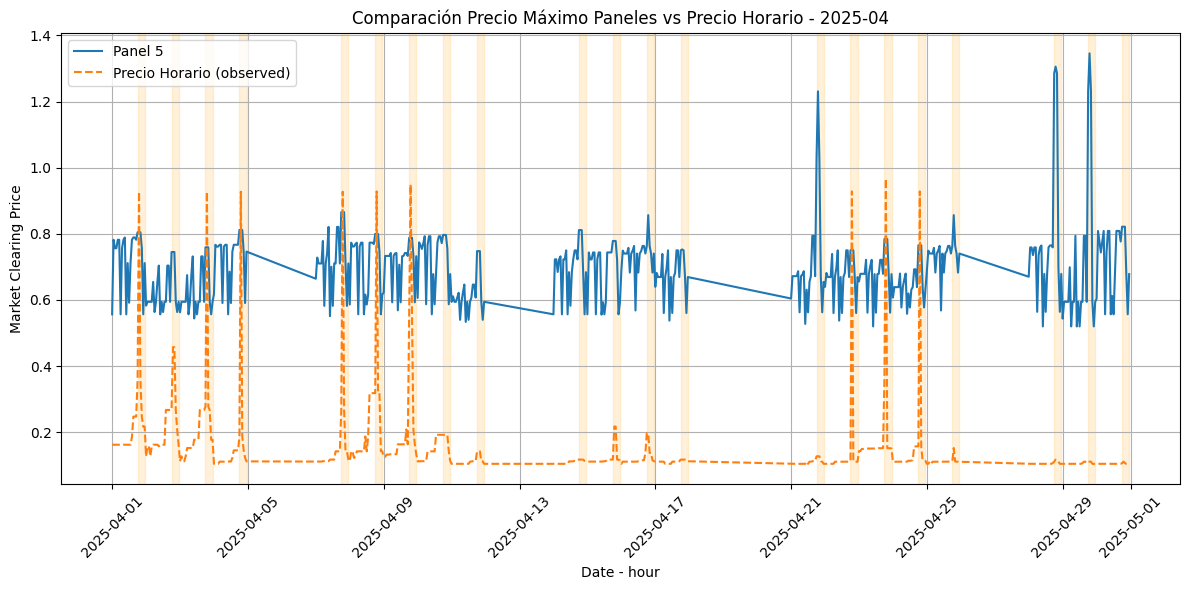

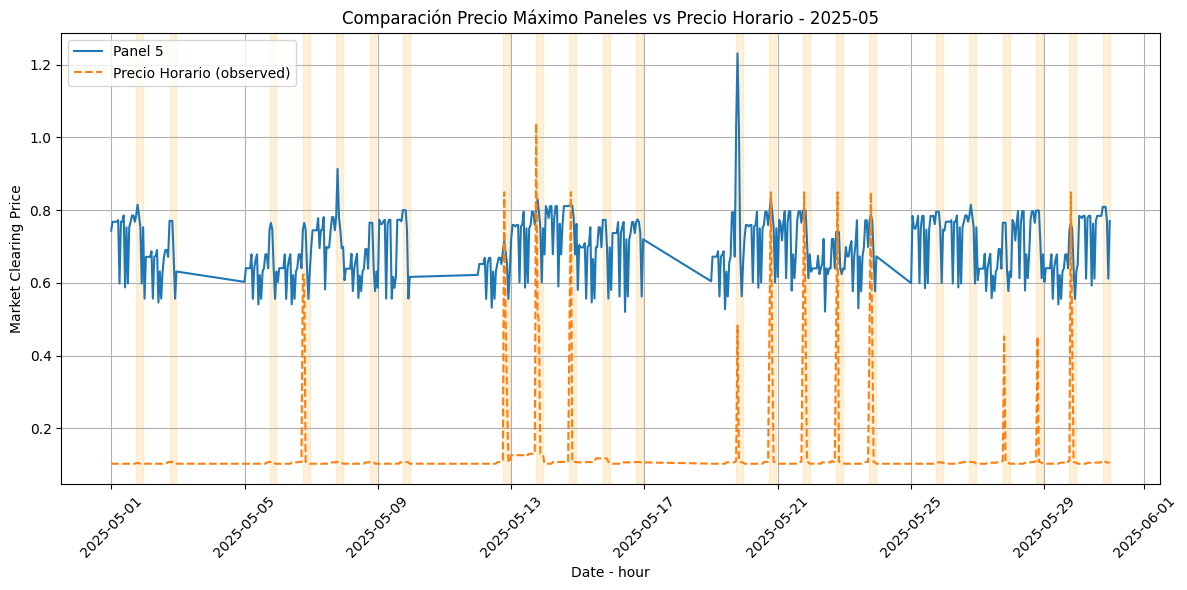

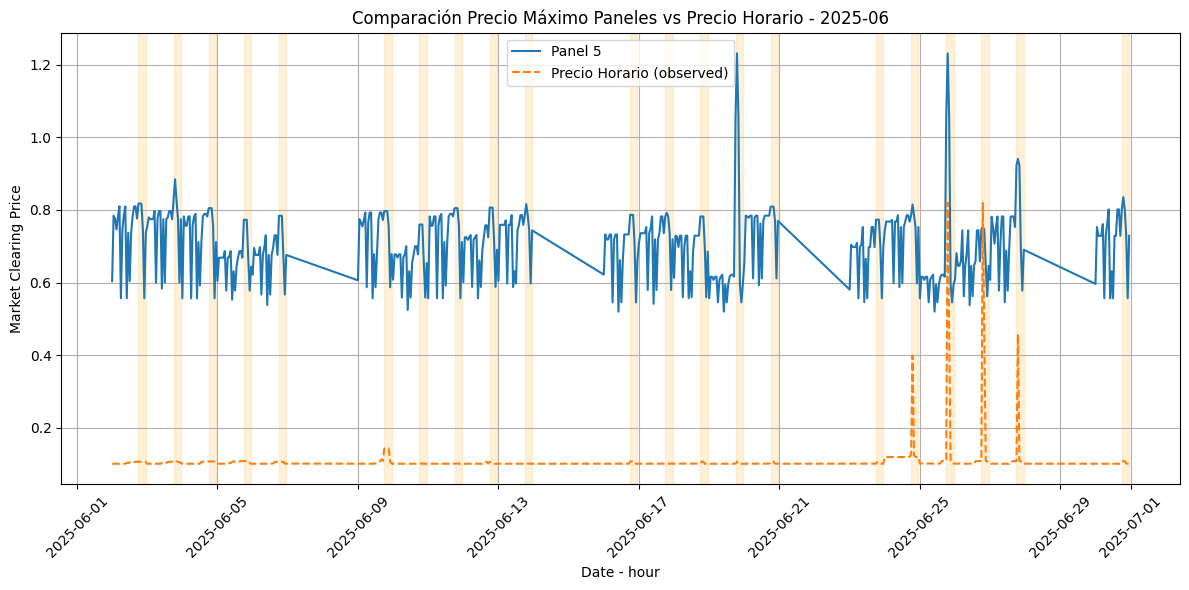

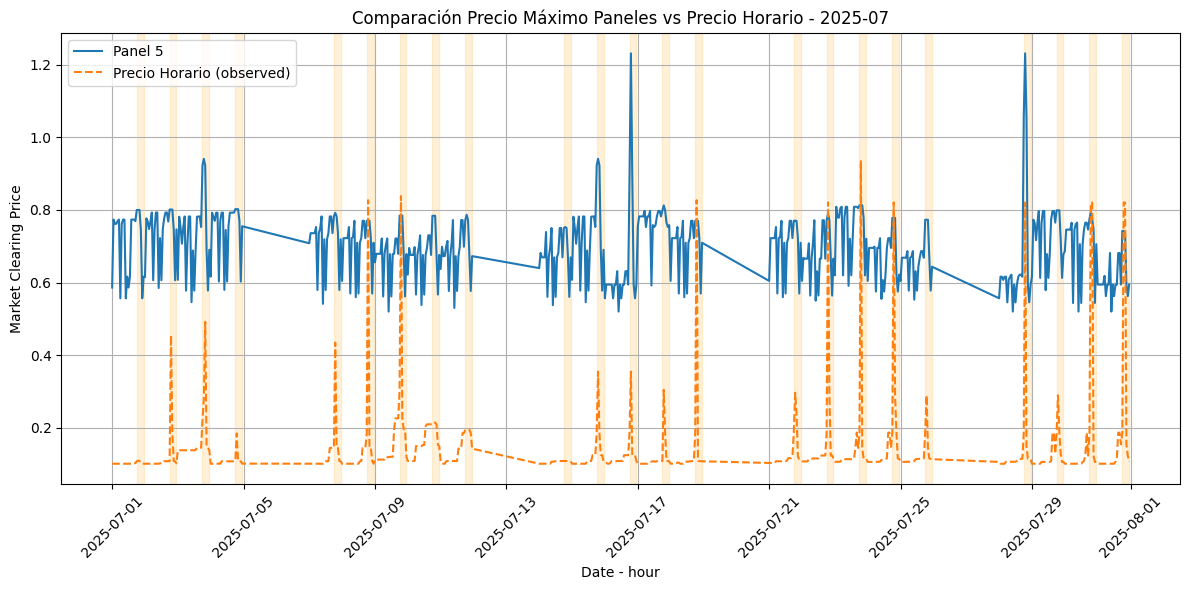

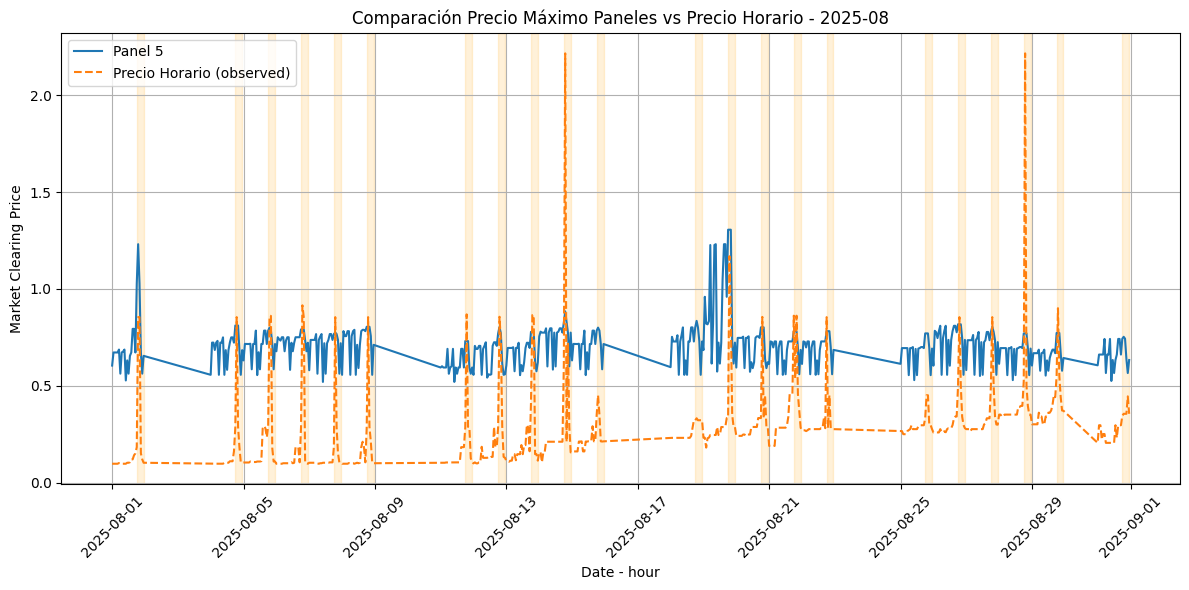

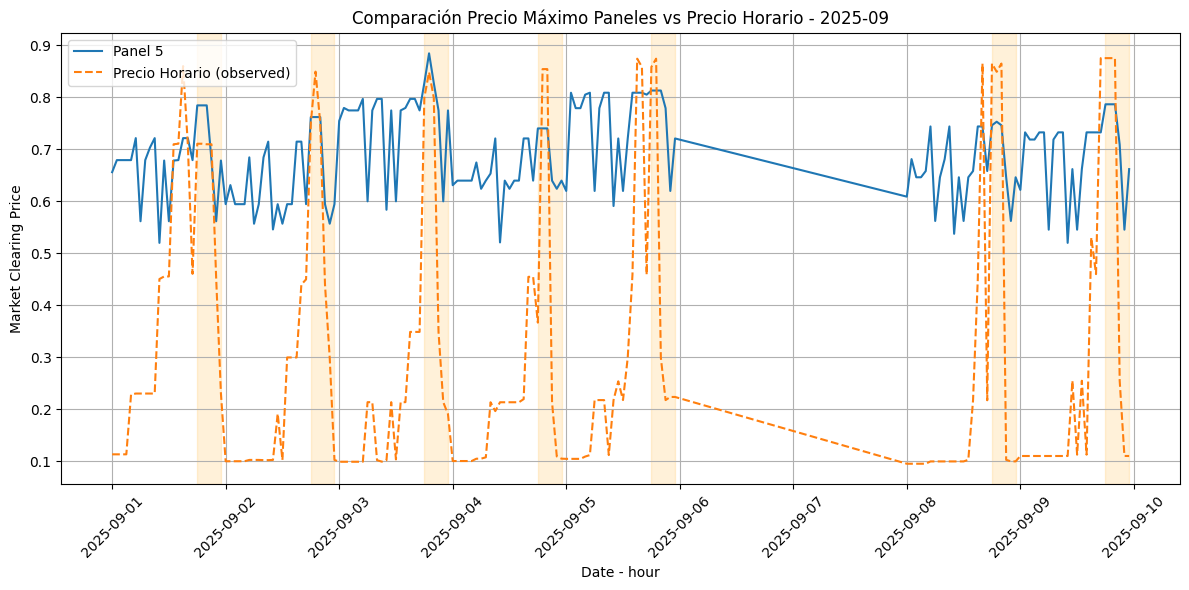

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df_combinado['Mes'] = df_combinado['FechaHora'].dt.to_period('M')

for mes, grupo in df_combinado.groupby('Mes'):
    
    fig, ax = plt.subplots(figsize=(12,6))
    
    #ax.plot(grupo['FechaHora'], grupo['Valor_panel1'], label='Panel 1')
    ax.plot(grupo['FechaHora'], grupo['Valor_panel5'], label='Panel 5')
    #ax.plot(grupo['FechaHora'], grupo['Valor_panel36'], label='Panel 36')
    ax.plot(grupo['FechaHora'], grupo['Valor_horario'], 
            linestyle='--', label='Precio Horario (observed)')
    
    # 🔹 Resaltar horas 18:00–23:00 día por día
    dias_unicos = grupo['FechaHora'].dt.date.unique()
    
    for dia in dias_unicos:
        inicio = pd.Timestamp(dia) + pd.Timedelta(hours=18)
        fin = pd.Timestamp(dia) + pd.Timedelta(hours=23)
        ax.axvspan(inicio, fin, color='orange', alpha=0.15)
    
    ax.set_xlabel('Date - hour')
    ax.set_ylabel('Market Clearing Price')
    ax.set_title(f'Comparación Precio Máximo Paneles vs Precio Horario - {mes}')
    ax.grid(True)
    plt.xticks(rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()



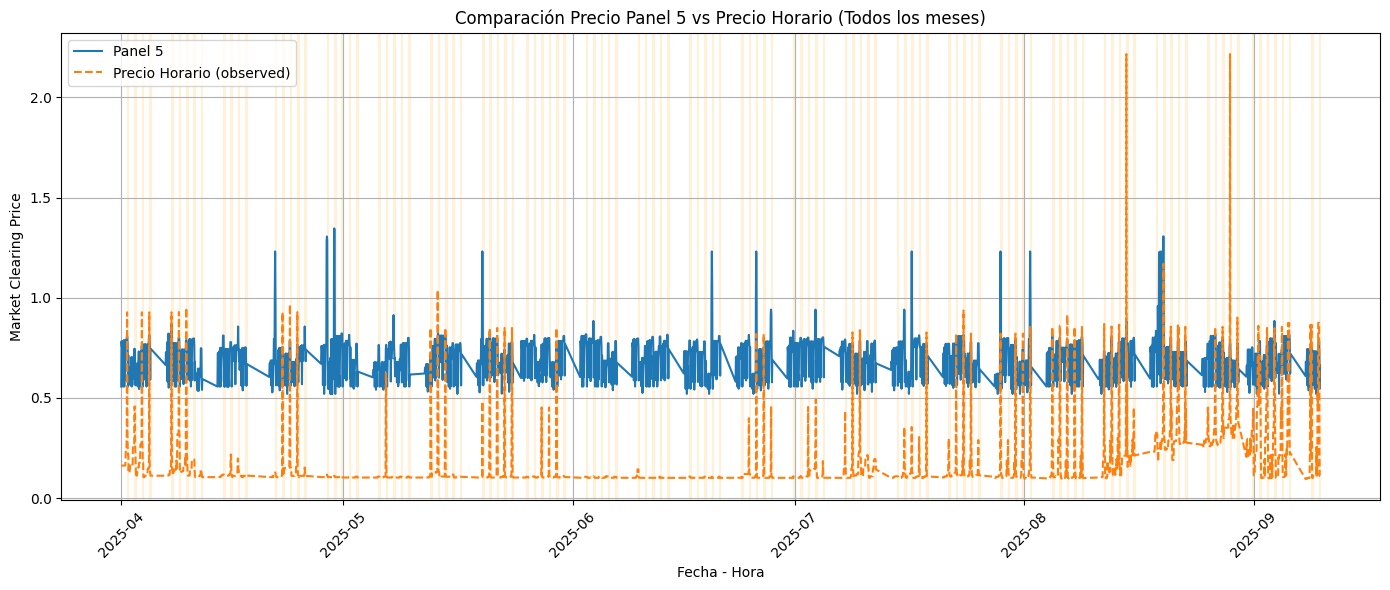

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df_combinado['FechaHora'] = pd.to_datetime(df_combinado['FechaHora'])

fig, ax = plt.subplots(figsize=(14,6))

ax.plot(df_combinado['FechaHora'], df_combinado['Valor_panel5'], label='Panel 5')
ax.plot(df_combinado['FechaHora'], df_combinado['Valor_horario'],
        linestyle='--', label='Precio Horario (observed)')

# Resaltar horas 18–23 en todo el periodo
dias_unicos = df_combinado['FechaHora'].dt.date.unique()

for dia in dias_unicos:
    inicio = pd.Timestamp(dia) + pd.Timedelta(hours=18)
    fin = pd.Timestamp(dia) + pd.Timedelta(hours=23)
    ax.axvspan(inicio, fin, color='orange', alpha=0.1)

ax.set_xlabel('Fecha - Hora')
ax.set_ylabel('Market Clearing Price')
ax.set_title('Comparación Precio Panel 5 vs Precio Horario (Todos los meses)')
ax.grid(True)
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()


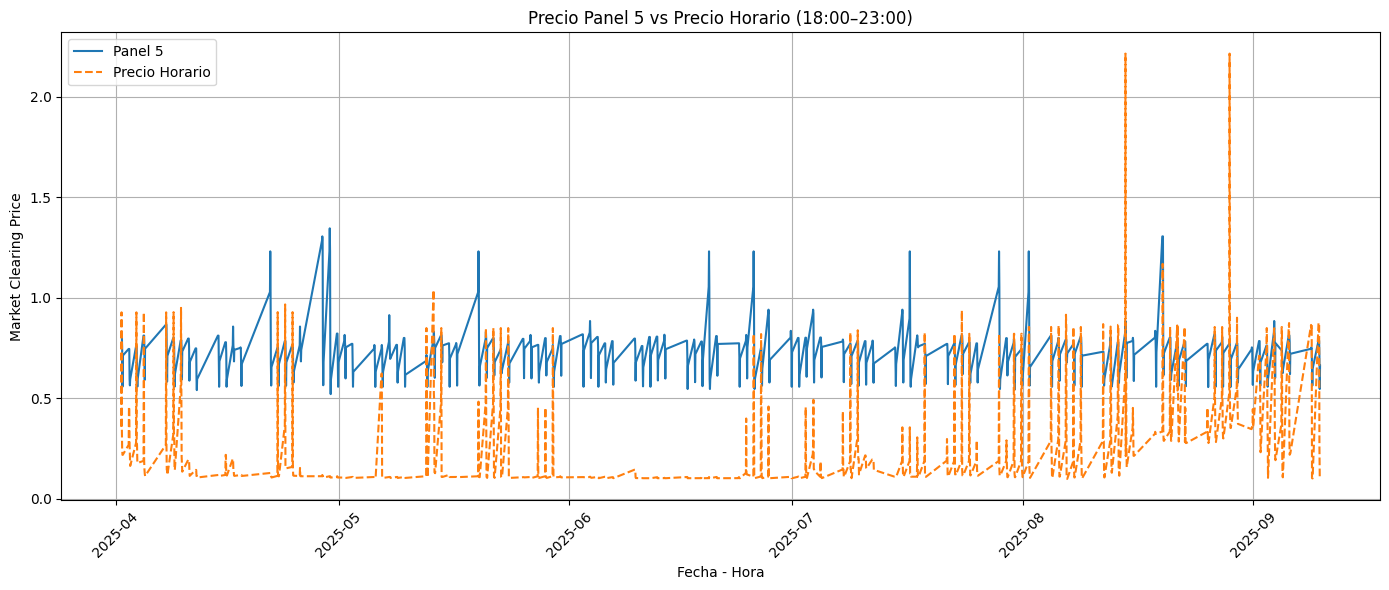

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Asegurar formato datetime
df_combinado['FechaHora'] = pd.to_datetime(df_combinado['FechaHora'])

# Filtrar solo horas 18 a 23
df_horas = df_combinado[
    df_combinado['FechaHora'].dt.hour.between(18, 23)
]

# Crear gráfico único
plt.figure(figsize=(14,6))

plt.plot(df_horas['FechaHora'], df_horas['Valor_panel5'], label='Panel 5')
plt.plot(df_horas['FechaHora'], df_horas['Valor_horario'],
         linestyle='--', label='Precio Horario')

plt.xlabel('Fecha - Hora')
plt.ylabel('Market Clearing Price')
plt.title('Precio Panel 5 vs Precio Horario (18:00–23:00)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
df_horas

,FechaHora,Valor_panel1,Valor_panel5,Valor_panleuniforme5menor,Valor_horario,Mes
18,2025-04-01 18:00:00,2.512666,0.804742,3.779208,0.35738,2025-04
19,2025-04-01 19:00:00,2.535885,0.804742,55.238758,0.92738,2025-04
20,2025-04-01 20:00:00,2.535885,0.804742,3.779208,0.35738,2025-04
21,2025-04-01 21:00:00,2.334456,0.756470,2.196485,0.24738,2025-04
22,2025-04-01 22:00:00,2.153372,0.556684,0.943010,0.21738,2025-04
...,...,...,...,...,...,...
2803,2025-09-09 19:00:00,2.502843,0.786382,504.223183,0.87507,2025-09
2804,2025-09-09 20:00:00,2.502843,0.786382,504.223183,0.87507,2025-09
2805,2025-09-09 21:00:00,2.502843,0.708756,0.946634,0.25514,2025-09
2806,2025-09-09 22:00:00,2.182893,0.545447,0.737270,0.11067,2025-09


## calculo despacho observado

In [ ]:

despacho = pd.read_csv('../../datos/raw/Despachoprogramadorecursosdegeneracion.csv', sep=',')

precio_horario = pd.read_csv('../../datos/raw/Preciodebolsahorario.csv')
filtro = (precio_horario['CodigoVariable'] == 'PB_Int') & (precio_horario['Version'] == 'TXF')
precio_horario = precio_horario[filtro]

In [ ]:
# Filtrar despacho por horas donde participan las temricas
despacho_termicas = despacho[
    (despacho['CodigoElementoGeneracion'].isin(input_red['CodigoPlanta'])) &
    (despacho['Valor'] > 0)
].copy()
despacho_termicas 


,FechaHora,CodigoDuracion,CodigoElementoGeneracion,Valor
160,2025-08-11 00:00:00,PT1H,TRN1,62000
162,2025-08-11 00:00:00,PT1H,TYP1,8000
163,2025-08-11 00:00:00,PT1H,TYP2,27000
169,2025-08-11 00:00:00,PT1H,ZPA2,17000
477,2025-08-11 01:00:00,PT1H,TBST,234000
...,...,...,...,...
1264302,2025-04-05 22:00:00,PT1H,TGJ2,72000
1264310,2025-04-05 22:00:00,PT1H,TRN1,62000
1264316,2025-04-05 22:00:00,PT1H,TYP1,8000
1264318,2025-04-05 22:00:00,PT1H,TYP3,49000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Supongamos que ya tienes tu DataFrame
# despacho_termicas = pd.read_csv("tu_archivo.csv")  # o como lo tengas cargado

# Asegurarse que FechaHora sea tipo datetime
despacho_termicas['FechaHora'] = pd.to_datetime(despacho_termicas['FechaHora'])

# Agrupar por FechaHora y sumar Valor
resumen = despacho_termicas.groupby('FechaHora')['Valor'].sum().reset_index()

resumen

,FechaHora,Valor
0,2025-04-01 00:00:00,1029700
1,2025-04-01 01:00:00,935380
2,2025-04-01 02:00:00,843320
3,2025-04-01 03:00:00,771690
4,2025-04-01 04:00:00,695000
...,...,...
3883,2025-09-09 19:00:00,1435200
3884,2025-09-09 20:00:00,1450100
3885,2025-09-09 21:00:00,1350180
3886,2025-09-09 22:00:00,1320240


## valor observado en miles de millones

In [ ]:
import pandas as pd

# Asegurarse de que FechaHora es datetime en ambos
despacho_termicas['FechaHora'] = pd.to_datetime(despacho_termicas['FechaHora'])
precio_horario['FechaHora'] = pd.to_datetime(precio_horario['FechaHora'])

# Merge por FechaHora
df_merged = despacho_termicas.merge(
    precio_horario[['FechaHora', 'Valor']],
    on='FechaHora',
    how='left',
    suffixes=('_despacho', '_precio')
)

# Multiplicar los valores
df_merged['Producto'] = df_merged['Valor_despacho'] * df_merged['Valor_precio']



In [ ]:
import pandas as pd

# Aseguramos que FechaHora sea datetime
df_merged['FechaHora'] = pd.to_datetime(df_merged['FechaHora'])

# Extraemos solo la fecha
df_merged['Fecha'] = df_merged['FechaHora'].dt.date

# Sumamos Producto por cada fecha
suma_diaria = df_merged.groupby('Fecha')['Producto'].sum()

# Calculamos el promedio de esos totales diarios
promedio_total = suma_diaria.mean()

print("Suma diaria por fecha:")
print(suma_diaria)
print("\nPromedio de la suma diaria de Producto:", promedio_total)




Suma diaria por fecha:
Fecha
2025-04-01    5.296467e+09
2025-04-02    4.984987e+09
2025-04-03    5.151035e+09
2025-04-04    3.460878e+09
2025-04-05    2.135100e+09
                  ...     
2025-09-05    1.012163e+10
2025-09-06    3.316063e+09
2025-09-07    1.990620e+09
2025-09-08    6.318353e+09
2025-09-09    7.780160e+09
Name: Producto, Length: 162, dtype: float64

Promedio de la suma diaria de Producto: 3752398877.6580243


## Valor observado verificado

In [ ]:
#miles de millones, en promedio para un dia de mi periodo!!
promedio_total/1000000000

np.float64(3.7523988776580244)

In [ ]:
df_merged

,FechaHora,CodigoDuracion,CodigoElementoGeneracion,Valor_despacho,Valor_precio,Producto,Fecha
0,2025-08-11 00:00:00,PT1H,TRN1,62000,102.82,6374840.0,2025-08-11
1,2025-08-11 00:00:00,PT1H,TYP1,8000,102.82,822560.0,2025-08-11
2,2025-08-11 00:00:00,PT1H,TYP2,27000,102.82,2776140.0,2025-08-11
3,2025-08-11 00:00:00,PT1H,ZPA2,17000,102.82,1747940.0,2025-08-11
4,2025-08-11 01:00:00,PT1H,TBST,234000,102.82,24059880.0,2025-08-11
...,...,...,...,...,...,...,...
35315,2025-04-05 22:00:00,PT1H,TGJ2,72000,112.68,8112960.0,2025-04-05
35316,2025-04-05 22:00:00,PT1H,TRN1,62000,112.68,6986160.0,2025-04-05
35317,2025-04-05 22:00:00,PT1H,TYP1,8000,112.68,901440.0,2025-04-05
35318,2025-04-05 22:00:00,PT1H,TYP3,49000,112.68,5521320.0,2025-04-05


## Cantidades

In [ ]:
import pandas as pd
import numpy as np
import ast

paneles = [panel_uniforme1, panel_uniforme5, panel_uniforme5menor
           , panel_uniforme36]
nombres_paneles = ['panel1', 'panel5', 'panel5menor', 'panel36']

# --- 1️⃣ Convertir cantidades_despachadas a array UNA sola vez ---
def convertir_lista_cantidades(x):
    if isinstance(x, str):
        return np.array(ast.literal_eval(x), dtype=float)
    elif isinstance(x, list):
        return np.array(x, dtype=float)
    elif isinstance(x, np.ndarray):
        return x.astype(float)
    else:
        return np.nan

for panel in paneles:
    panel['cantidades24'] = panel['cantidades_despachadas'].apply(convertir_lista_cantidades)

# --- 2️⃣ Construcción del DataFrame de cantidades máximas por hora ---
resumen_cantidades = []

todos_h = sorted(set().union(*[p['h'].unique() for p in paneles]))

for h_val in todos_h:
    fecha = None
    for p in paneles:
        if h_val in p['h'].values:
            fecha = p.loc[p['h']==h_val, 'Fecha'].iloc[0]
            break
    if fecha is None:
        continue

    for hora_idx in range(24):
        fila = {'FechaHora': fecha + pd.to_timedelta(hora_idx, unit='h')}

        for panel, nombre in zip(paneles, nombres_paneles):
            filas_h = panel[panel['h'] == h_val]

            if len(filas_h) == 0:
                fila[f'Cant_{nombre}'] = np.nan
                continue

            try:
                arr_cantidades = np.vstack(filas_h['cantidades24'])
                fila[f'Cant_{nombre}'] = arr_cantidades[:, hora_idx].max()
            except:
                fila[f'Cant_{nombre}'] = np.nan

        resumen_cantidades.append(fila)

# --- 3️⃣ DataFrame final de cantidades ---
df_max_cantidades = (
    pd.DataFrame(resumen_cantidades)
    .sort_values('FechaHora')
    .reset_index(drop=True)
)

df_max_cantidades.head()


,FechaHora,Cant_panel1,Cant_panel5,Cant_panel5menor,Cant_panel36
0,2025-04-01 00:00:00,255.00000,160.00,160.0,191.54
1,2025-04-01 01:00:00,255.00000,209.21,160.0,791.00
2,2025-04-01 02:00:00,118.05107,160.00,160.0,640.76
3,2025-04-01 03:00:00,63.00000,160.00,160.0,543.75
4,2025-04-01 04:00:00,255.00000,160.00,160.0,774.89


In [ ]:
import pandas as pd

# Asegurarse de que FechaHora es datetime
despacho_termicas['FechaHora'] = pd.to_datetime(despacho_termicas['FechaHora'])
df_max_cantidades['FechaHora'] = pd.to_datetime(df_max_cantidades['FechaHora'])
despacho_termicas['ValorMWh']=despacho_termicas['Valor']/1000
# Agrupar despacho_termicas por FechaHora y sumar Valor
valor_por_hora = despacho_termicas.groupby('FechaHora')['ValorMWh'].sum().reset_index()

# Hacer merge con df_max_cantidades
df_max_cantidades = df_max_cantidades.merge(
    valor_por_hora,
    on='FechaHora',
    how='left'
)

df_max_cantidades.head()


,FechaHora,Cant_panel1,Cant_panel5,Cant_panel5menor,Cant_panel36,Mes,ValorMWh
0,2025-04-01 00:00:00,255.00000,160.00,160.0,191.54,2025-04,1029.70
1,2025-04-01 01:00:00,255.00000,209.21,160.0,791.00,2025-04,935.38
2,2025-04-01 02:00:00,118.05107,160.00,160.0,640.76,2025-04,843.32
3,2025-04-01 03:00:00,63.00000,160.00,160.0,543.75,2025-04,771.69
4,2025-04-01 04:00:00,255.00000,160.00,160.0,774.89,2025-04,695.00


In [ ]:
df_max_cantidades

,FechaHora,Cant_panel1,Cant_panel5,Cant_panel5menor,Cant_panel36,Mes,ValorMWh
0,2025-04-01 00:00:00,255.00000,160.00,160.0,191.54000,2025-04,1029.70
1,2025-04-01 01:00:00,255.00000,209.21,160.0,791.00000,2025-04,935.38
2,2025-04-01 02:00:00,118.05107,160.00,160.0,640.76000,2025-04,843.32
3,2025-04-01 03:00:00,63.00000,160.00,160.0,543.75000,2025-04,771.69
4,2025-04-01 04:00:00,255.00000,160.00,160.0,774.89000,2025-04,695.00
...,...,...,...,...,...,...,...
2803,2025-09-09 19:00:00,753.38000,445.00,445.0,791.00000,2025-09,1435.20
2804,2025-09-09 20:00:00,628.04000,445.00,445.0,791.00000,2025-09,1450.10
2805,2025-09-09 21:00:00,255.00000,160.00,160.0,445.00000,2025-09,1350.18
2806,2025-09-09 22:00:00,255.00000,92.00,92.0,123.22918,2025-09,1320.24


In [ ]:
import pandas as pd

# Supongamos que ya tienes df_max_cantidades con las columnas:
# 'FechaHora', 'Cant_panel1', 'Cant_panel5', 'Cant_panel36', 'ValorMWh'

# 1️⃣ Convertimos FechaHora a datetime (por si acaso)
df_max_cantidades['FechaHora'] = pd.to_datetime(df_max_cantidades['FechaHora'])

# 2️⃣ Creamos columna de mes (año-mes) para agrupar
df_max_cantidades['Mes'] = df_max_cantidades['FechaHora'].dt.to_period('M')

# 3️⃣ Agrupamos por mes y sumamos las cantidades y promedio del ValorMWh
resumen_mensual = df_max_cantidades.groupby('Mes').agg(
    Cant_panel1=('Cant_panel1', 'sum'),
    Cant_panel5=('Cant_panel5', 'sum'),
    Cant_panel6=('Cant_panel5menor', 'sum'),
    Cant_panel36=('Cant_panel36', 'sum'),
    ValorMWh=('ValorMWh', 'sum')  # promedio del valor
).reset_index()

# 4️⃣ Convertimos Mes de period a string para visualización
resumen_mensual['Mes'] = resumen_mensual['Mes'].astype(str)

resumen_mensual.head()


,Mes,Cant_panel1,Cant_panel5,Cant_panel6,Cant_panel36,ValorMWh
0,2025-04,163117.37145,132026.99734,118979.87055,283376.64671,474949.67
1,2025-05,165052.04738,136146.89293,133346.18712,308211.59328,440103.49
2,2025-06,150784.34493,121699.60987,125505.94225,282110.79409,455637.04
3,2025-07,201026.22425,137960.86974,141832.34850,309219.60355,494832.02
4,2025-08,171735.79784,130193.01996,134095.78215,294505.08542,549436.55


In [ ]:
df_combinado_despacho_termica

,FechaHora,Valor_panel1,Valor_panel5,Valor_panel36,Valor_horario
0,2025-04-01 00:00:00,2.073490,0.556684,0.943010,0.16238
1,2025-04-01 01:00:00,2.037606,0.782121,2.927221,0.16238
2,2025-04-01 02:00:00,1.934166,0.756470,2.196485,0.16238
3,2025-04-01 03:00:00,1.934166,0.756470,1.260578,0.16238
4,2025-04-01 04:00:00,2.037606,0.782121,2.369250,0.16238
...,...,...,...,...,...
2803,2025-09-09 19:00:00,2.502843,0.786382,504.223183,0.87507
2804,2025-09-09 20:00:00,2.502843,0.786382,504.223183,0.87507
2805,2025-09-09 21:00:00,2.502843,0.708756,0.946634,0.25514
2806,2025-09-09 22:00:00,2.182893,0.545447,0.737270,0.11067


## Input red

In [ ]:
# Asegurarse que la columna sea datetime
input_red['Fecha'] = pd.to_datetime(input_red['Fecha'])

# Ordenar de menor a mayor
input_red = input_red.sort_values(by='Fecha', ascending=True)

# (Opcional) resetear índice
input_red = input_red.reset_index(drop=True)
input_red


,CodigoPlanta,available_q,phi,precio_d,daily_reman_demand,Fecha,cluster,id_planta
0,TBQ4,"[60000.0, 60000.0, 60000.0, 60000.0, 60000.0, ...","1412,9929207591","1436,3400000000","[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,"10,0000000000",33
1,TCDT,"[555000.0, 555000.0, 555000.0, 555000.0, 55500...","714,7773786599","891,2700000000","[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,"10,0000000000",30
2,GE32,"[255000.0, 255000.0, 255000.0, 255000.0, 25500...","217,3255060574","288,9200000000","[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,"10,0000000000",9
3,TFL1,"[160000.0, 160000.0, 160000.0, 160000.0, 16000...","1356,6745100345","1436,5400000000","[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,"10,0000000000",21
4,ZPA5,"[63000.0, 63000.0, 63000.0, 63000.0, 63000.0, ...","326,5074323042","344,3700000000","[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,"10,0000000000",14
...,...,...,...,...,...,...,...,...
4207,TGJ2,"[92000.0, 92000.0, 92000.0, 92000.0, 92000.0, ...","1911,4967108493","1963,3500000000","[860580.0, 580630.0, 322051.0700000003, 256310...",2025-09-09,NaN,20
4208,GEC3,"[164000.0, 164000.0, 164000.0, 164000.0, 16400...","115,7175349203","244,0200000000","[860580.0, 580630.0, 322051.0700000003, 256310...",2025-09-09,"12,0000000000",13
4209,TRM1,"[46000.0, 46000.0, 46000.0, 46000.0, 46000.0, ...","855,9496887016","899,6200000000","[860580.0, 580630.0, 322051.0700000003, 256310...",2025-09-09,NaN,18
4210,MRL1,"[164000.0, 164000.0, 164000.0, 164000.0, 16400...","835,3431483875","976,5700000000","[860580.0, 580630.0, 322051.0700000003, 256310...",2025-09-09,"12,0000000000",5


In [ ]:
input_red[input_red['Fecha']=='2025-04-01']

,CodigoPlanta,available_q,phi,precio_d,daily_reman_demand,Fecha,cluster,id_planta
0,TBQ4,"[60000.0, 60000.0, 60000.0, 60000.0, 60000.0, ...","1412,9929207591","1436,3400000000","[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,"10,0000000000",33
1,TCDT,"[555000.0, 555000.0, 555000.0, 555000.0, 55500...","714,7773786599","891,2700000000","[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,"10,0000000000",30
2,GE32,"[255000.0, 255000.0, 255000.0, 255000.0, 25500...","217,3255060574","288,9200000000","[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,"10,0000000000",9
3,TFL1,"[160000.0, 160000.0, 160000.0, 160000.0, 16000...","1356,6745100345","1436,5400000000","[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,"10,0000000000",21
4,ZPA5,"[63000.0, 63000.0, 63000.0, 63000.0, 63000.0, ...","326,5074323042","344,3700000000","[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,"10,0000000000",14
5,TBQ3,"[60000.0, 60000.0, 60000.0, 60000.0, 60000.0, ...","1419,2912866422","1442,0500000000","[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,"10,0000000000",34
6,TVL1,"[241000.0, 241000.0, 241000.0, 241000.0, 24100...","1117,7176778360","1191,9000000000","[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,"10,0000000000",35
7,PPA4,"[165000.0, 165000.0, 165000.0, 165000.0, 16500...","231,2068897417","281,6300000000","[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,"10,0000000000",10
8,CTG1,"[52000.0, 52000.0, 52000.0, 52000.0, 52000.0, ...","1700,4734546191","1727,7900000000","[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,"10,0000000000",27
9,GEC3,"[164000.0, 164000.0, 164000.0, 164000.0, 16400...","223,1804608391","272,2300000000","[238087.97000000067, 1032624.4100000001, 83845...",2025-04-01,"10,0000000000",13


In [ ]:
panel_uniforme36

,t,h,id_planta,phi,bid_scalar,cantidades_despachadas,precio24,payment24,Fecha,cantidades24
0,0,0,1,"[0.07175805856629999, 0.07175805856629999, 0.0...",7.836186e-01,"[92.0, 92.0, 92.0, 92.0, 92.0, 92.0, 92.0, 92....","[0.9430101381072998, 1.015164630247116, 0.9502...",2197.934027,2025-04-01,"[92.0, 92.0, 92.0, 92.0, 92.0, 92.0, 92.0, 92...."
1,0,0,2,"[0.9466334040629999, 0.9466334040629999, 0.946...",1.669968e+00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9430101381072998, 1.015164630247116, 0.9502...",0.000000,2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,0,0,3,"[0.2283073328238, 0.2283073328238, 0.228307332...",1.015165e+00,"[0.0, 84.21000000000004, 0.0, 0.0, 6.889999999...","[0.9430101381072998, 1.015164630247116, 0.9502...",995.153452,2025-04-01,"[0.0, 84.21000000000004, 0.0, 0.0, 6.889999999..."
3,0,0,4,"[0.2235823991822, 0.2235823991822, 0.223582399...",9.937407e-01,"[0.0, 92.0, 0.0, 0.0, 92.0, 92.0, 0.0, 0.0, 92...","[0.9430101381072998, 1.015164630247116, 0.9502...",1176.006188,2025-04-01,"[0.0, 92.0, 0.0, 0.0, 92.0, 92.0, 0.0, 0.0, 92..."
4,0,0,5,"[0.9730122853209, 0.9730122853209, 0.973012285...",2.165068e+00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9430101381072998, 1.015164630247116, 0.9502...",0.000000,2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...,...,...,...,...,...,...
421195,99,116,32,"[0.9004858934074, 0.9004858934074, 0.900485893...",6.119422e+21,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1562914566526413, 0.18293726606464386, 0.15...",0.000000,2025-09-09,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
421196,99,116,33,"[1.1162621275357, 1.1162621275357, 1.116262127...",1.468641e+20,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1562914566526413, 0.18293726606464386, 0.15...",0.000000,2025-09-09,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
421197,99,116,34,"[1.1263563027462, 1.1263563027462, 1.126356302...",1.586097e+20,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1562914566526413, 0.18293726606464386, 0.15...",0.000000,2025-09-09,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
421198,99,116,35,"[1.0807253604175, 1.0807253604175, 1.080725360...",9.583668e+22,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1562914566526413, 0.18293726606464386, 0.15...",0.000000,2025-09-09,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [ ]:
import numpy as np
import ast

# --- 1️⃣ Convertir cantidades_despachadas a array UNA sola vez ---
def convertir_lista_cantidades(x):
    if isinstance(x, str):
        return np.array(ast.literal_eval(x), dtype=float)
    elif isinstance(x, list):
        return np.array(x, dtype=float)
    elif isinstance(x, np.ndarray):
        return x.astype(float)
    else:
        return np.nan  # mantiene consistencia

for panel in paneles:
    panel['cantidades24'] = panel['cantidades_despachadas'].apply(convertir_lista_cantidades)

import numpy as np

mask = panel_uniforme1['h'] == 0

suma_h0 = np.sum(
    np.stack(panel_uniforme36.loc[mask, 'cantidades24'])[:, 0]
)

print("Suma total (h=0, primera componente):", suma_h0)



AssertionError: 

In [ ]:
panel_uniforme1[panel_uniforme1['h'] == 0]

,id_planta,t,h,bid,cantidades_despachadas,precio24,phi,Fecha,cantidades24
0,1,0,0,2.676840,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.8268800727022, 0.8268800727022, 0.826880072...",2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,2,0,0,3.564928,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.7148847113195, 1.7148847113195, 1.714884711...",2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,3,0,0,3.467680,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.6176457155191, 1.6176457155191, 1.617645715...",2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,4,0,0,2.041678,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1917712637032, 0.1917712637032, 0.191771263...",2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,5,0,0,2.037606,"[164.0, 113.63, 0.0, 0.0, 17.920000000000016, ...","[2.073489846421242, 2.037606479359627, 0.0, 0....","[0.18770034673480002, 0.18770034673480002, 0.1...",2025-04-01,"[164.0, 113.63, 0.0, 0.0, 17.920000000000016, ..."
5,6,0,0,2.822986,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9730122853209, 0.9730122853209, 0.973012285...",2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6,7,0,0,2.135033,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.2851207751719, 0.2851207751719, 0.285120775...",2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
7,8,0,0,2.086626,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.23671749990899998, 0.23671749990899998, 0.2...",2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
8,9,0,0,2.124290,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.2743795666479, 0.2743795666479, 0.274379566...",2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
9,10,0,0,2.044515,"[165.0, 0.0, 0.0, 0.0, 0.0, 39.76999999999998,...","[2.073489846421242, 0.0, 0.0, 0.0, 0.0, 2.0445...","[0.19460868678329998, 0.19460868678329998, 0.1...",2025-04-01,"[165.0, 0.0, 0.0, 0.0, 0.0, 39.76999999999998,..."


In [ ]:
panel_uniforme5

,id_planta,t,h,bid,cantidades_despachadas,precio24,phi,Fecha,cantidades24
0,1,0,0,0.591779,"[0.0, 92.0, 92.0, 92.0, 92.0, 92.0, 0.0, 92.0,...","[0.0, 0.7821207046508789, 0.7564698457717896, ...","[0.07175805856629999, 0.07175805856629999, 0.0...",2025-04-01,"[0.0, 92.0, 92.0, 92.0, 92.0, 92.0, 0.0, 92.0,..."
1,2,0,0,1.466651,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9466334040629999, 0.9466334040629999, 0.946...",2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,3,0,0,0.822712,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.2283073328238, 0.2283073328238, 0.228307332...",2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,4,0,0,0.817988,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.2235823991822, 0.2235823991822, 0.223582399...",2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,5,0,0,1.567388,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9730122853209, 0.9730122853209, 0.973012285...",2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...,...,...,...,...,...
4207,32,0,116,1.381648,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.8617673362902, 0.8617673362902, 0.861767336...",2025-09-09,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4208,33,0,116,1.739308,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.2190602927523, 1.2190602927523, 1.219060292...",2025-09-09,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4209,34,0,116,1.742629,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.2223766098828, 1.2223766098828, 1.222376609...",2025-09-09,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4210,35,0,116,2.332031,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0982876247439002, 1.0982876247439002, 1.098...",2025-09-09,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


Bid mínimo global: 0.5535
Bid máximo global: 4.0431


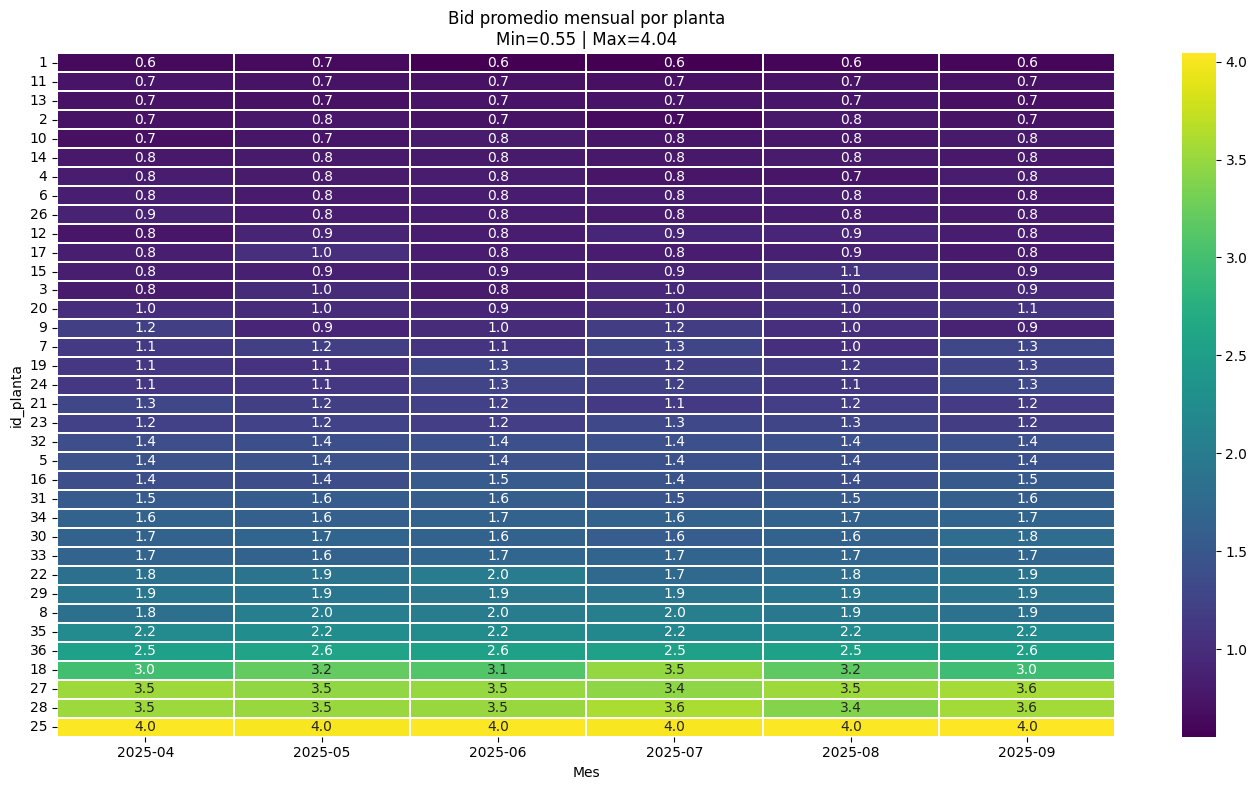

Mes,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09
id_planta,,,,,,
1,0.645521,0.660053,0.561996,0.553526,0.595591,0.610221
11,0.742440,0.723590,0.714663,0.701274,0.723203,0.709968
13,0.730498,0.716809,0.735706,0.730783,0.744501,0.696443
2,0.726297,0.766686,0.720443,0.660689,0.778441,0.719274
10,0.697636,0.744503,0.800765,0.750739,0.763360,0.791144
14,0.778222,0.795188,0.791815,0.785182,0.799689,0.780264
4,0.839102,0.809720,0.819467,0.757959,0.745297,0.833172
6,0.848965,0.800913,0.829934,0.819571,0.823975,0.775130
26,0.891101,0.816701,0.815056,0.808365,0.821903,0.804909


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def heatmap_bid_mensual(panel,
                        fecha_col='Fecha',
                        planta_col='id_planta',
                        bid_col='bid',
                        cmap='viridis',
                        annot=True):
    """
    Genera heatmap del bid promedio mensual por planta,
    ordenado por bid promedio total.
    """

    df = panel.copy()

    # Asegurar formato fecha
    df[fecha_col] = pd.to_datetime(df[fecha_col])
    df['Mes'] = df[fecha_col].dt.to_period('M')

    # Promedio mensual por planta
    df_mensual = (
        df
        .groupby([planta_col, 'Mes'])[bid_col]
        .mean()
        .reset_index()
    )

    # Pivot
    heatmap_data = df_mensual.pivot(
        index=planta_col,
        columns='Mes',
        values=bid_col
    )

    # Ordenar por bid promedio total
    orden = heatmap_data.mean(axis=1).sort_values().index
    heatmap_data = heatmap_data.loc[orden]

    # Min y Max global
    vmin = heatmap_data.min().min()
    vmax = heatmap_data.max().max()

    print(f"Bid mínimo global: {vmin:.4f}")
    print(f"Bid máximo global: {vmax:.4f}")

    # Graficar
    plt.figure(figsize=(14,8))
    sns.heatmap(
        heatmap_data,
        cmap=cmap,
        linewidths=0.1,
        annot=annot,
        fmt=".1f" if annot else "",
        vmin=vmin,
        vmax=vmax
    )

    plt.title(f'Bid promedio mensual por planta\nMin={vmin:.2f} | Max={vmax:.2f}')
    plt.xlabel('Mes')
    plt.ylabel(planta_col)
    plt.tight_layout()
    plt.show()

    return heatmap_data


heatmap_bid_mensual(panel_uniforme5)




In [ ]:
panel_uniforme36

,t,h,id_planta,phi,bid_scalar,cantidades_despachadas,precio24,payment24,Fecha,cantidades24
0,0,0,1,"[0.07175805856629999, 0.07175805856629999, 0.0...",7.836186e-01,"[92.0, 92.0, 92.0, 92.0, 92.0, 92.0, 92.0, 92....","[0.9430101381072998, 1.015164630247116, 0.9502...",2197.934027,2025-04-01,"[92.0, 92.0, 92.0, 92.0, 92.0, 92.0, 92.0, 92...."
1,0,0,2,"[0.9466334040629999, 0.9466334040629999, 0.946...",1.669968e+00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9430101381072998, 1.015164630247116, 0.9502...",0.000000,2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,0,0,3,"[0.2283073328238, 0.2283073328238, 0.228307332...",1.015165e+00,"[0.0, 84.21000000000004, 0.0, 0.0, 6.889999999...","[0.9430101381072998, 1.015164630247116, 0.9502...",995.153452,2025-04-01,"[0.0, 84.21000000000004, 0.0, 0.0, 6.889999999..."
3,0,0,4,"[0.2235823991822, 0.2235823991822, 0.223582399...",9.937407e-01,"[0.0, 92.0, 0.0, 0.0, 92.0, 92.0, 0.0, 0.0, 92...","[0.9430101381072998, 1.015164630247116, 0.9502...",1176.006188,2025-04-01,"[0.0, 92.0, 0.0, 0.0, 92.0, 92.0, 0.0, 0.0, 92..."
4,0,0,5,"[0.9730122853209, 0.9730122853209, 0.973012285...",2.165068e+00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.9430101381072998, 1.015164630247116, 0.9502...",0.000000,2025-04-01,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...,...,...,...,...,...,...
421195,99,116,32,"[0.9004858934074, 0.9004858934074, 0.900485893...",6.119422e+21,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1562914566526413, 0.18293726606464386, 0.15...",0.000000,2025-09-09,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
421196,99,116,33,"[1.1162621275357, 1.1162621275357, 1.116262127...",1.468641e+20,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1562914566526413, 0.18293726606464386, 0.15...",0.000000,2025-09-09,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
421197,99,116,34,"[1.1263563027462, 1.1263563027462, 1.126356302...",1.586097e+20,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1562914566526413, 0.18293726606464386, 0.15...",0.000000,2025-09-09,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
421198,99,116,35,"[1.0807253604175, 1.0807253604175, 1.080725360...",9.583668e+22,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1562914566526413, 0.18293726606464386, 0.15...",0.000000,2025-09-09,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [ ]:
import pandas as pd
import numpy as np
import ast

paneles = [panel_uniforme1, panel_uniforme5, panel_uniforme36]
nombres_paneles = ['panel1', 'panel5', 'panel36']

# Convertir cantidades_despachadas a array de 24 horas
def convertir_lista_cantidades(x):
    if isinstance(x, str):
        return np.array(ast.literal_eval(x), dtype=float)
    elif isinstance(x, list):
        return np.array(x, dtype=float)
    elif isinstance(x, np.ndarray):
        return x.astype(float)
    else:
        return np.nan

for panel in paneles:
    panel['cantidades24'] = panel['cantidades_despachadas'].apply(convertir_lista_cantidades)

# Generar filas por hora y panel
resumen_paneles = []

for panel, nombre in zip(paneles, nombres_paneles):
    for idx, row in panel.iterrows():
        fecha = row['Fecha']
        planta = row['id_planta']
        cantidades = row['cantidades24']
        if isinstance(cantidades, np.ndarray) and len(cantidades) == 24:
            for hora_idx, cantidad in enumerate(cantidades):
                resumen_paneles.append({
                    'FechaHora': pd.to_datetime(fecha) + pd.to_timedelta(hora_idx, unit='h'),
                    'id_planta': planta,
                    f'Cantidad_{nombre}': cantidad
                })

# Crear DataFrame y pivotear para tener columnas por panel
df_cantidades_paneles = pd.DataFrame(resumen_paneles)

# Pivot para que cada columna sea un panel, agregando sum si hay repetidos
df_cantidades_paneles = df_cantidades_paneles.groupby(['FechaHora', 'id_planta']).sum().reset_index()

df_cantidades_paneles.head()


,FechaHora,id_planta,Cantidad_panel1,Cantidad_panel5,Cantidad_panel36
0,2025-04-01,1,0.0,0.0,3772.00
1,2025-04-01,2,0.0,0.0,2912.32
2,2025-04-01,3,0.0,0.0,1211.08
3,2025-04-01,4,0.0,0.0,1141.70
4,2025-04-01,5,164.0,0.0,7.54
